In [37]:
import torch
import glob, os
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from cnn_connectome.datasets.natural_movie import resolve_data_path
import seaborn as sns
sns.set_context("talk")
plt.rcParams['figure.dpi'] = 90

In [13]:
data_path = resolve_data_path()
mat_files = sorted(glob.glob(os.path.join(data_path, "*.mat")))
if not mat_files:
    raise FileNotFoundError("No .mat files found in directory")
print(f"Found {len(mat_files)} .mat files")

Found 398 .mat files


## Dataset stats

In [29]:
all_imgs = []
file_names = []

PERCENTILE_SCALE = 99

for fname in mat_files:
    with h5py.File(fname, "r") as f:
        if "projection" not in f:
            raise KeyError(f"{fname} does not contain 'projection'")
        img = np.array(f["projection"]).T.astype(np.float32)

    all_imgs.append(img)
    file_names.append(os.path.basename(fname))

all_imgs = np.array(all_imgs)
scene_scale = np.percentile(all_imgs, PERCENTILE_SCALE, axis=(1,2))   # per image, 99th percentile of each image
corpus_scale = np.percentile(all_imgs, PERCENTILE_SCALE)              # one number, 99th percentile across all images

print("Final all_imgs shape:", all_imgs.shape)
print("Range:", all_imgs.min(), all_imgs.max())



Final all_imgs shape: (398, 251, 927)
Range: 0.0 23900.0


In [15]:
def show_hdr(img, ax=None, mode="log", lo=1, hi=99.5, title=None,
             extent=None, horizon_row=None):
    """Display-only tone map. Input: raw or scaled linear radiance."""
    x = np.asarray(img, dtype=np.float64)
    pos = x[x > 0]
    floor = np.percentile(pos, 0.1) if pos.size else 1e-8

    if mode == "log":
        y = np.log10(np.maximum(x, floor))
    elif mode == "gamma":
        y = np.power(np.maximum(x, 0) / np.percentile(x, hi), 1 / 2.2)
    else:
        y = x

    vmin, vmax = np.percentile(y, [lo, hi])
    ax = ax or plt.gca()
    ax.imshow(y, cmap="gray", vmin=vmin, vmax=vmax,
              interpolation="nearest", aspect="equal", extent=extent)
    if horizon_row is not None:
        ax.axhline(horizon_row, color="tab:red", lw=0.5)
    if title:
        ax.set_title(title, fontsize=8)
    ax.set_axis_off()
    return ax


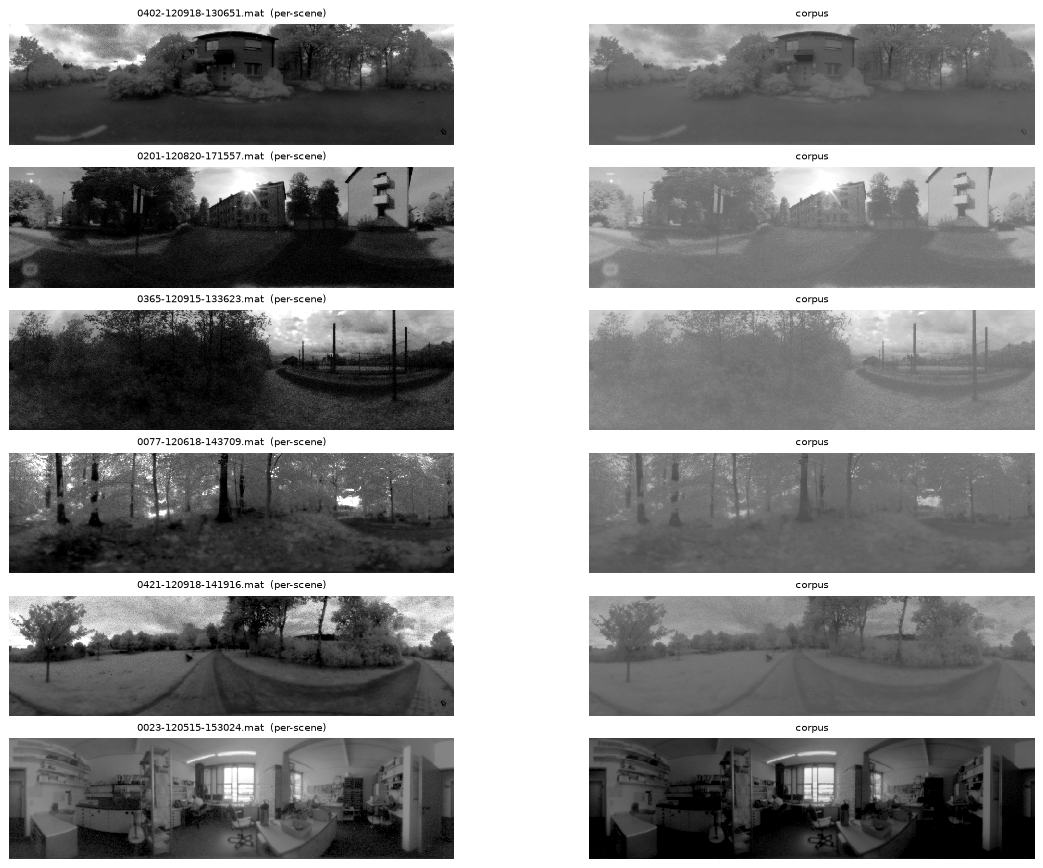

In [24]:
n_imgs = 6
n = np.random.choice(len(all_imgs), n_imgs, replace=False)
fig, axes = plt.subplots(n_imgs, 2, figsize=(14, 1.6 * n_imgs))

for idx, i in enumerate(n):
    # middle: per-scene normalized — what your pipeline currently produces
    show_hdr(all_imgs[i] / scene_scale[i], ax=axes[idx, 0],
             title=f"{file_names[i][:28]}  (per-scene)")
    # right: corpus normalized, SHARED display range
    show_hdr(all_imgs[i] / corpus_scale, ax=axes[idx, 1],
             lo=0, hi=100, title="corpus")

# force a common vmin/vmax on the right column so brightness is comparable
y_all = np.log10(np.maximum(all_imgs / corpus_scale, 1e-6))
vmin, vmax = np.percentile(y_all, [1, 99.5])
for idx in range(n_imgs):
    axes[idx, 1].images[0].set_clim(vmin, vmax)

fig.tight_layout()

In [41]:
## plot a single img with hist
from matplotlib.gridspec import GridSpec
def plot_image_hist(img, idx, fname, q=99):
    v = np.percentile(np.abs(img), q)          # symmetric, outlier-robust

    fig = plt.figure(figsize=(6, 5), constrained_layout=True)
    gs = GridSpec(2, 1, figure=fig, height_ratios=[2, 1])

    ax_img = fig.add_subplot(gs[0, 0])
    im = ax_img.imshow(img, cmap="RdBu_r", vmin=-1.0, vmax=v,
                       aspect="equal", interpolation="nearest")
    fig.colorbar(im, ax=ax_img, fraction=0.02)
    ax_img.set_xticks([]); ax_img.set_yticks([])
    ax_img.set_title(f"Weber contrast — idx {idx} — {fname[:28]}", fontsize=10)

    ax_hist = fig.add_subplot(gs[1, 0])
    ax_hist.hist(img.ravel(), bins=256, color="gray", density=True)
    ax_hist.set_yscale("log")                  # the tail is the interesting part
    ax_hist.axvline(0, color="k", ls="--", lw=1)
    ax_hist.axvline(-1, color="tab:red", ls=":", lw=1)   # hard floor
    ax_hist.set_xlabel("Crude Weber contrast"); ax_hist.set_ylabel("density")
    plt.show()

Contrast range: -1.0 81.12528


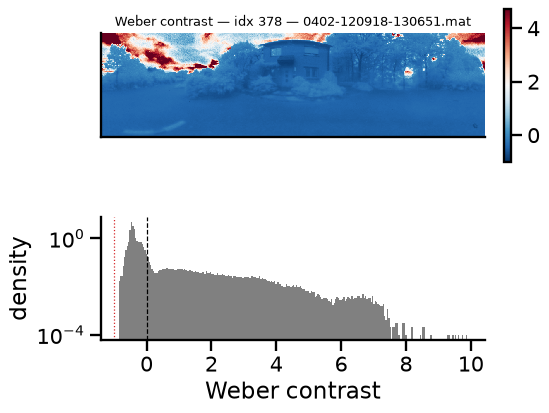

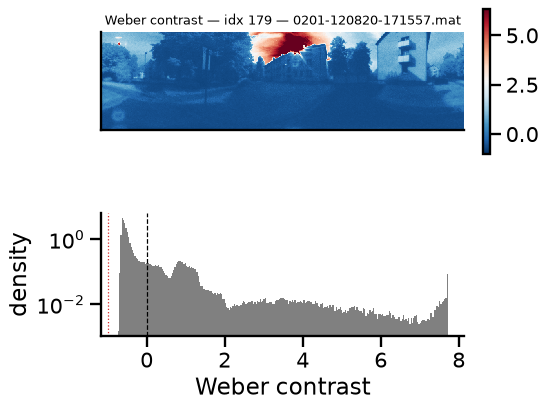

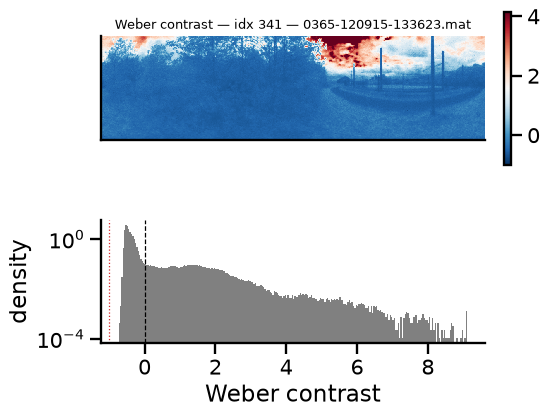

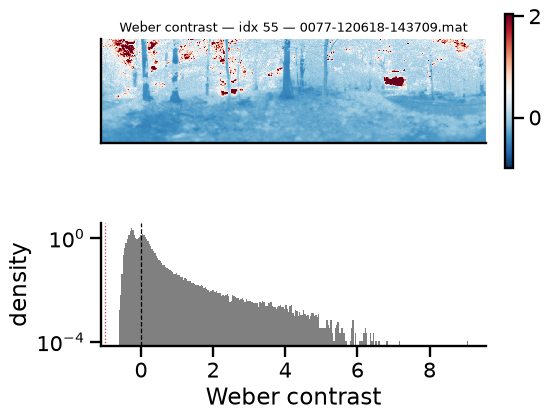

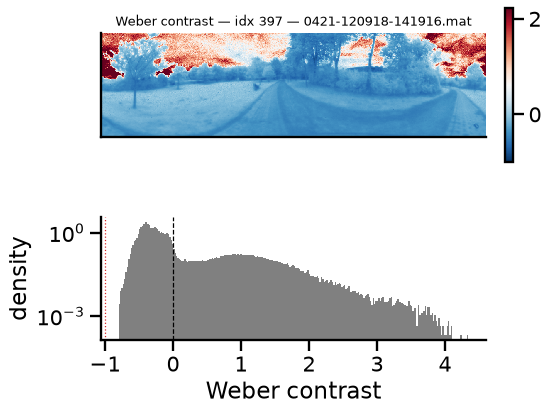

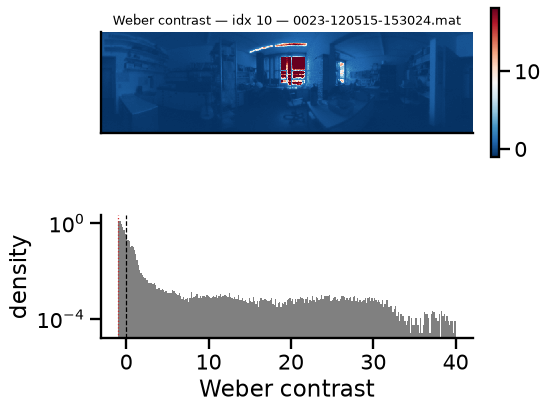

In [40]:
means = all_imgs.mean(axis=(1, 2), keepdims=True) #spatial mean per image

all_contrast = (all_imgs - means) /(means + 1e-8) # Weber contrast per image

print("Contrast range:", all_contrast.min(), all_contrast.max())
for _, i in enumerate(n):
    plot_image_hist(
        all_contrast[i],
        i,
        file_names[i]
    )